In [17]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.model_selection import train_test_split

In [18]:
# Applicazione di Machine Learning e Valutazione Modelli.
# Creo un solo dataframe (df) che conterrà il contenuto di entrmambi i file csv

DATASET_DIRECTORY ="../Data/"

df1 = pd.read_csv(os.path.join(DATASET_DIRECTORY, "Merged01.csv"))
df2 = pd.read_csv(os.path.join(DATASET_DIRECTORY, "Merged02.csv"))

df = pd.concat([df1, df2], axis=0, ignore_index=True)

In [19]:
# Da X_colums ho tolto le colonne che dallo studio svolto nel file study.ipynb sono risultate rumore
# colonne tolte: rst_flag_number,Variance,LLC,ARP,fin_count, syn_count, rst_count, ack_count, Header_Length,psh_flag_number e Protocol Type
X_columns = [
        'Time_To_Live', 'Rate',
       'fin_flag_number', 'syn_flag_number',
        'ack_flag_number', 'ece_flag_number',
       'cwr_flag_number', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP',
       'SSH', 'IRC', 'TCP', 'UDP','DHCP', 'ICMP', 'IGMP', 'IPv', 
       'Tot sum', 'Min', 'Max','AVG', 'Std', 'Tot size', 'IAT', 'Number',
]

# Effettuo un encoding della colonna target in modo da trasformare ogni tipo di attacco in un valore numerico
#faccio una mappatura a mano per essere più preciso
mappatura_label = {
    'BENIGN': 0,
    'DDOS-PSHACK_FLOOD': 1,
    'MIRAI-GREIP_FLOOD': 2,
    'DOS-UDP_FLOOD': 3,
    'DNS_SPOOFING': 4,
    'DDOS-ICMP_FLOOD': 5,
    'DDOS-TCP_FLOOD': 6,
    'DDOS-SYN_FLOOD': 7,
    'DDOS-UDP_FLOOD': 8,
    'MITM-ARPSPOOFING': 9,
    'DDOS-SYNONYMOUSIP_FLOOD': 10,
    'DOS-TCP_FLOOD': 11,
    'VULNERABILITYSCAN': 12,
    'DOS-SYN_FLOOD': 13,
    'DDOS-RSTFINFLOOD': 14,
    'DDOS-SLOWLORIS': 15,
    'DDOS-ICMP_FRAGMENTATION': 16,
    'MIRAI-GREETH_FLOOD': 17,
    'RECON-HOSTDISCOVERY': 18,
    'MIRAI-UDPPLAIN': 19,
    'RECON-PORTSCAN': 20,
    'DDOS-ACK_FRAGMENTATION': 21,
    'DDOS-UDP_FRAGMENTATION': 22,
    'RECON-OSSCAN': 23,
    'BACKDOOR_MALWARE': 24,
    'DOS-HTTP_FLOOD': 25,
    'XSS': 26,
    'DDOS-HTTP_FLOOD': 27,
    'BROWSERHIJACKING': 28,
    'SQLINJECTION': 29,
    'DICTIONARYBRUTEFORCE': 30,
    'COMMANDINJECTION': 31,
    'RECON-PINGSWEEP': 32,
    'UPLOADING_ATTACK': 33
}
df['Label'] = df['Label'].map(mappatura_label)
y_column = 'Label'

# rimuovo in oltre le righe del dataset che contengono valori inf o nulli nelle colonne : STD e Rete
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

X = df[X_columns]
y = df[y_column]

#import seaborn as sns
#corr_matrix_DF1 = df[X_columns].corr()
#plt.figure(figsize=(24, 18))
#sns.heatmap(corr_matrix_DF1, annot=True, cmap='coolwarm', linewidths=0.5,vmin=-1, vmax=1)


In [20]:
# Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error

#faccio un primo test con un 70%-30%, poi provo altre percentuali, sarà tutto salvato in delle note 
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
print(f"MSE: {mse*100:.2f}")
print(f"RMSE: {rmse*100:.2f}")

# --- RISULTATI REGRESSIONE LINEARE ---
# Test con 70%-30%: MSE: 948.66 | RMSE: 308.00
# Test con 80%-20%: MSE: 946.83 | RMSE: 307.71
# Test con 60%-40%: MSE: 950.21 | RMSE: 308.25

# OSSERVAZIONE:
# Le prestazioni del modello risultano scadenti, penso che il motivo sia un errata scelta del modello di ML
# la Regressione Lineare è progettata per stimare variabili continue, il nostro target, al contrario, è una variabile nominale. 
# I valori numerici assegnati agli attacchi fungono da semplici etichette e non possiedono  alcun significato matematico o ordinale.
# Concludo dicendo che, l'approccio regressivo è inefficace. Nelle sezioni successive il problema verrà affrontato utilizzando modelli differenti.

MSE: 948.66
RMSE: 308.00


Accuracy: 0.73
Precision: 0.74
Recall: 0.73
F1-Score: 0.69


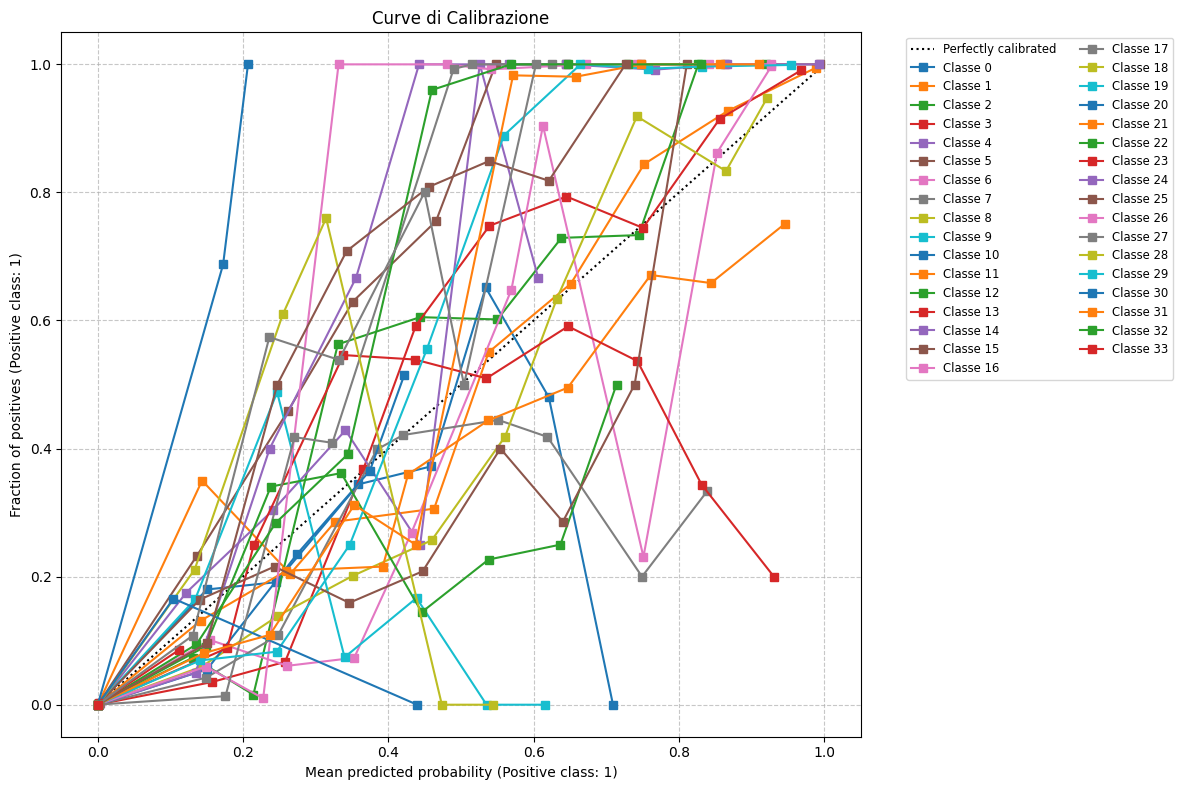


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.50      0.99      0.67      6823
           1       0.99      0.99      0.99     25475
           2       0.60      0.30      0.40      4624
           3       0.93      0.28      0.43     20531
           4       0.44      0.01      0.03      1070
           5       1.00      1.00      1.00     44945
           6       0.57      0.91      0.70     27832
           7       0.42      0.77      0.54     25139
           8       0.69      0.99      0.81     33422
           9       0.10      0.00      0.00      1938
          10       0.51      0.31      0.39     22536
          11       0.55      0.18      0.27     16680
          12       0.15      0.04      0.07      2315
          13       0.44      0.03      0.05     12597
          14       1.00      1.00      1.00     25108
          15       0.22      0.31      0.26       144
          16       0.96      0.97      0.96      2781
    

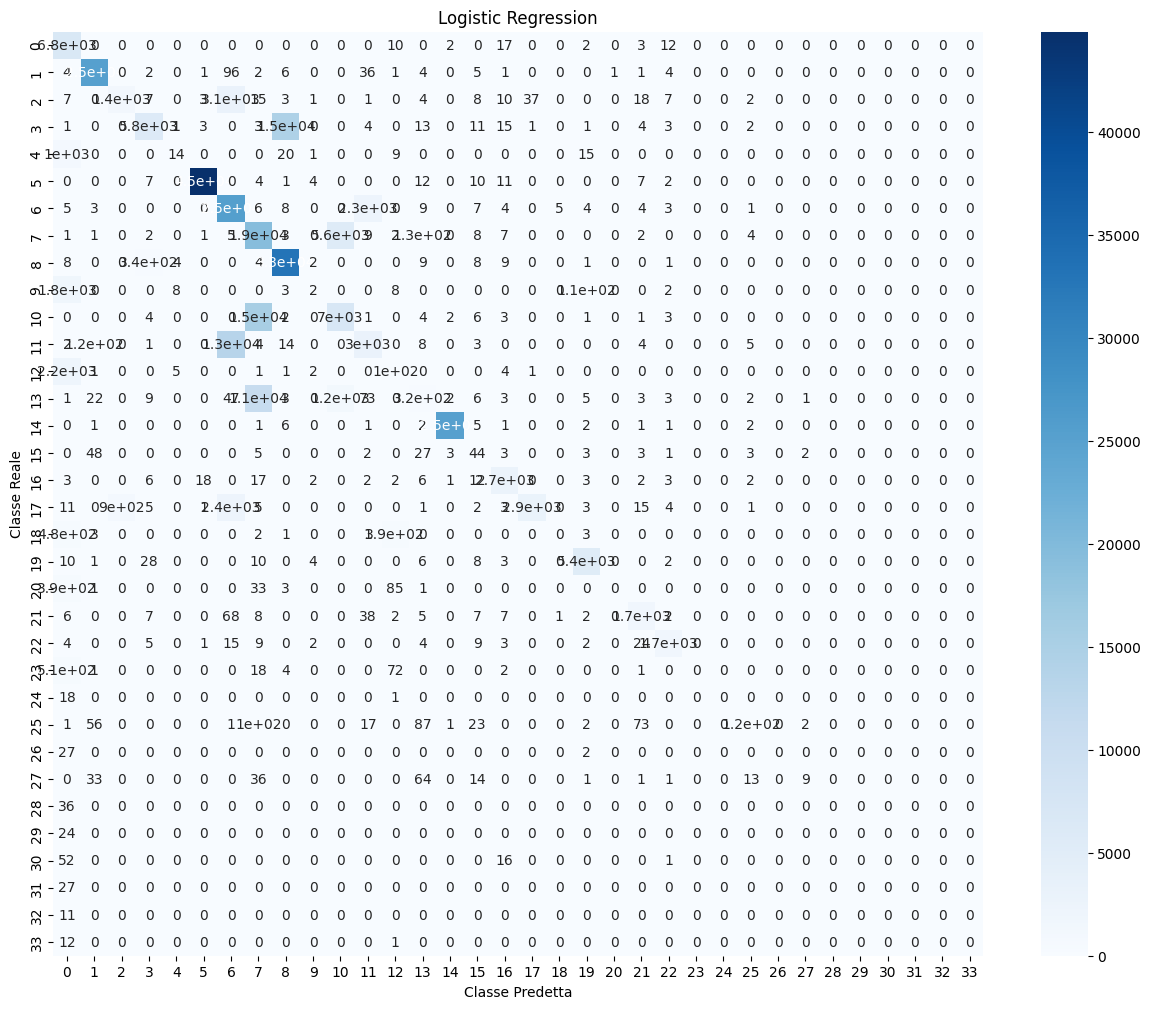

In [ ]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

#from sklearn.preprocessing import RobustScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

lr_model = LogisticRegression(
    solver='lbfgs',                        
    max_iter=500,
    C=1.0,                      # Per evitare overfitting
    class_weight='balanced',
    #n_jobs=-1,                 
    random_state=42,
    tol=1e-3                    # più tolleranza per risparmiare tempo
)

calibrated_lr = CalibratedClassifierCV(lr_model, method='isotonic', cv=3)

calibrated_lr.fit(X_train,y_train)
y_pred_log = calibrated_lr.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_log)
precision = precision_score(y_test, y_pred_log, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred_log, average='weighted')
f1 = f1_score(y_test, y_pred_log, average='weighted')
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# -- GRAFICI --
y_prob = calibrated_lr.predict_proba(X_test)

plt.figure(figsize=(12, 8))
asse_grafico = plt.gca()                #Seleziona l'asse, necessario per fare il grafico

for classe in range(34):
    y_binario = (y_test == classe).astype(int)
    prob_classe = y_prob[:, classe]
    
    CalibrationDisplay.from_predictions(
        y_binario,                   
        prob_classe,               
        n_bins=10,                        # Divide il grafico in 10 "tappe" da 0 a 100%
        name=f"Classe {classe}",          
        ax=asse_grafico                   # Diciamo di disegnare tutto sullo stesso grafico
    )

plt.title("Curve di Calibrazione")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize='small')
plt.tight_layout() # Sistema i margini
plt.show()

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred_log, zero_division=0))

print("\nCONFUSION MATRIX")
cm = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True,fmt='g', annot_kws={"size":7}, cmap='Blues',cbar=True)
plt.title('Logistic Regression')
plt.xlabel('Classe Predetta')
plt.ylabel('Classe Reale')
plt.show()

#TEST
# Prova con solver = saga e max_iter = 100, Risultati: Accuracy: 0.68, Precision: 0.73, Recall: 0.68, F1-Score: 0.68 T_esec 5:03 -- risultati dovuti al max_iter troppo basso, ma aumentandolo si allungherebbero di troppo i tempi di esecuzione
# Prova con solver = lbfgs e max_iter = 500, Risutlati: Accuracy: 0.72, Precision: 0.75, Recall: 0.72, F1-Score: 0.71 T_esec : 5:26 -- risultati migliori grazie all'aumento delle iterazioni ma ancora tempi troppo lunghi per i risultati ottenuti
# Prova con solver = lbfgs e max_iter = 500 ma rimuovendo C=1.0, Risutlati: Accuracy: 0.72, Precision: 0.75, Recall: 0.72, F1-Score: 0.71 T_esec : 5:28 -- risultati identici, non era la regolarizzazione a dare problemi
# Prova con solver = lbfgs e max_iter = 500 ma utilizzando uno scaler dviverso (RobustScaler): Accuracy: 0.53, Precision: 0.57, Recall: 0.53, F1-Score: 0.51 -- Pessimo

#OSSERVAZIONI
# La logistic regression non raggiunge i livelli di accuratezza desiderati e soprattutto impega molto più tempo di altri modelli che arrivano a risultati migliori in meno tempo.
# Aumentando il numero di iterazioni si potrebbe puntare ad ottenere risultati migliori ma a netto discapito delle tempistiche che sono gia eccessivamente lunghe.

#TEST 2 
# Prova con solver = lbfgs e max_iter = 500 e aggiunta calibrazione con CalibratedClassifierCV Risultati: Accuracy: 0.73, Precision: 0.74, Recall: 0.73, F1-Score: 0.69 T_Esec: 9:54 -- Noto che con la calibrazione l'accuratezza è aumentata ma è diminuito drasticamente l'F1_score. Inoltre sono aumentati anche i tempi di esecuzione
# L'analisi del grafico mostra una grave insabilità, in alucni casi il modello sottostima e in altri sovrastima. Dimostra che per alcune classi il nostro modello è molto performante ma per altre prorpio no. Unica nota positiva sembra overperformare quando la classe da indovinare è benigna. 

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy: 0.78
Precision: 0.79
Recall: 0.78
F1-Score: 0.77


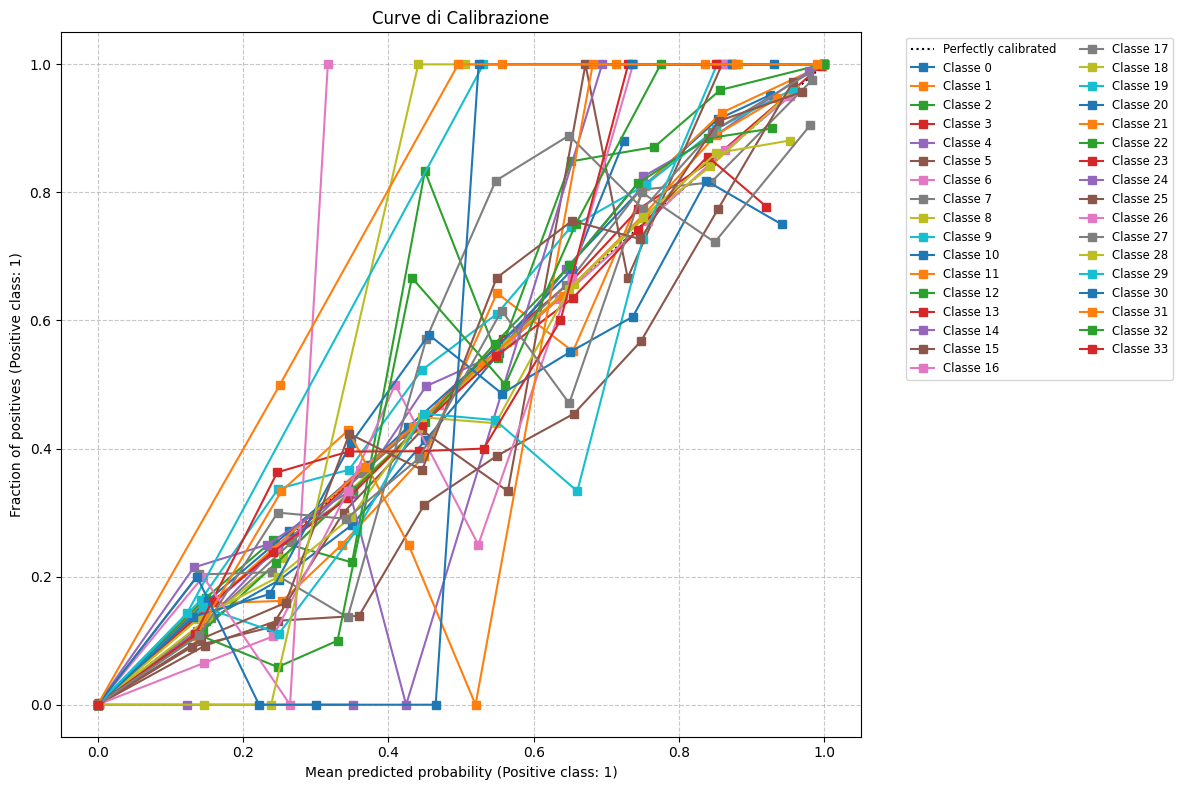


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.75      0.91      0.82      6823
           1       1.00      1.00      1.00     25475
           2       0.99      1.00      0.99      4624
           3       0.81      0.46      0.59     20531
           4       0.75      0.64      0.69      1070
           5       1.00      1.00      1.00     44945
           6       0.69      0.84      0.76     27832
           7       0.52      0.40      0.45     25139
           8       0.74      0.93      0.82     33422
           9       0.82      0.71      0.76      1938
          10       0.46      0.73      0.57     22536
          11       0.59      0.38      0.46     16680
          12       0.60      0.60      0.60      2315
          13       0.62      0.26      0.36     12597
          14       1.00      1.00      1.00     25108
          15       0.44      0.87      0.59       144
          16       0.96      0.99      0.97      2781
    

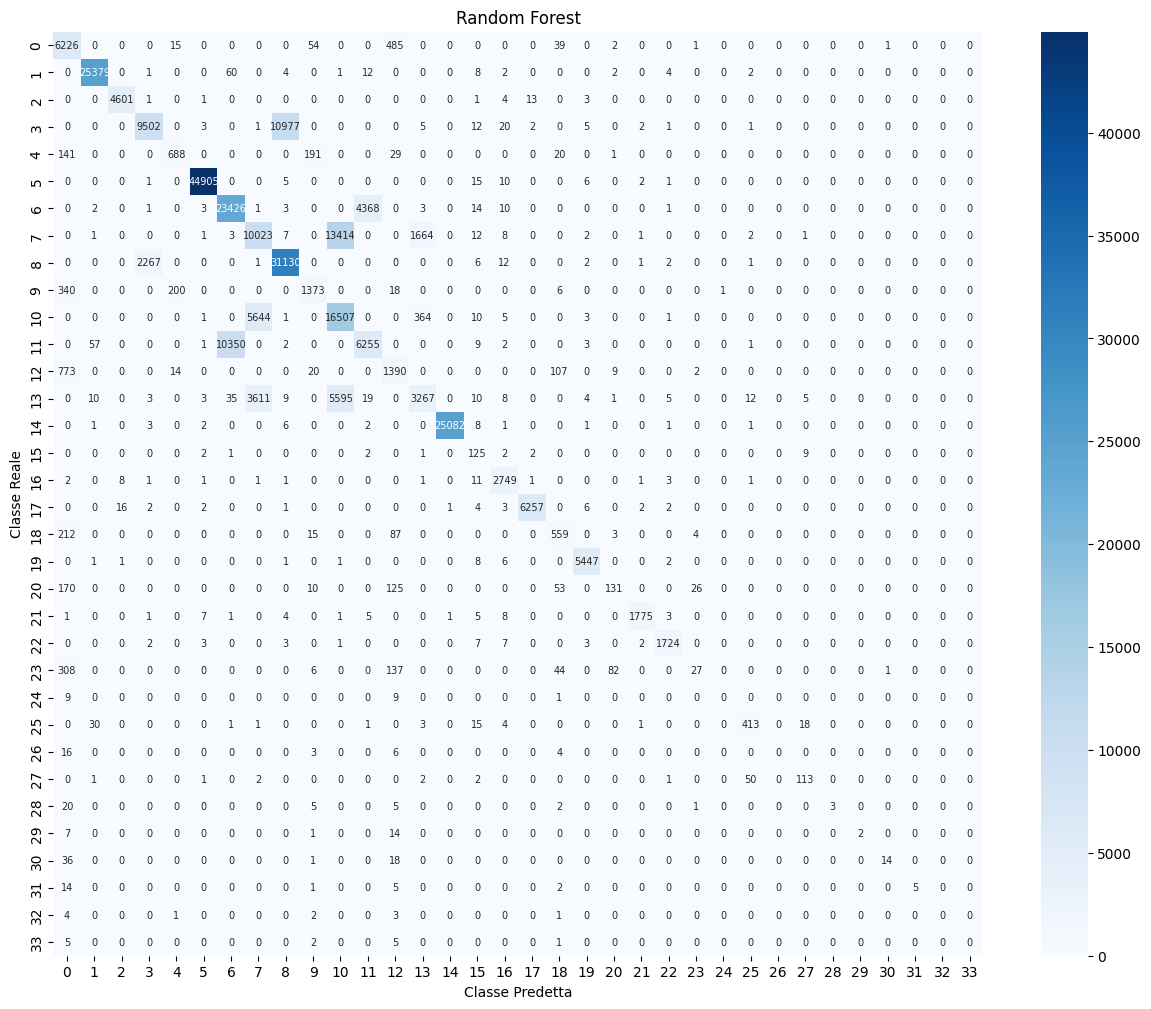

In [22]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=20,                          # Aggiungo un max_depth così da poter non far crushare la ram
    class_weight='balanced',                # Necessario per bilanciare gli output a causa dello sbilanciamento del dataset
    random_state=42, 
    n_jobs=-1
)

calibrated_rf = CalibratedClassifierCV(rf_model, method='isotonic', cv=3)
calibrated_rf.fit(X_train, y_train)

y_pred_rf = calibrated_rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf, average='weighted')
recall = recall_score(y_test, y_pred_rf, average='weighted')
f1 = f1_score(y_test, y_pred_rf, average='weighted')                # Il fatto che questo valore sia simile all'accuratezza fa intendere che il modello non va in overfiitng ma indovina anche i valori più rari
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# -- GRAFICI --
y_prob = calibrated_rf.predict_proba(X_test)

plt.figure(figsize=(12, 8))
asse_grafico = plt.gca()

for classe in range(34):
    y_binario = (y_test == classe).astype(int)
    prob_classe = y_prob[:, classe]
    
    CalibrationDisplay.from_predictions(
        y_binario,                   
        prob_classe,               
        n_bins=10,                        
        name=f"Classe {classe}",          
        ax=asse_grafico                  
    )

plt.title("Curve di Calibrazione")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize='small')
plt.tight_layout() 
plt.show()

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred_rf, zero_division=0))

print("\nCONFUSION MATRIX")
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True,fmt='g', annot_kws={"size":7}, cmap='Blues',cbar=True)
plt.title('Random Forest')
plt.xlabel('Classe Predetta')
plt.ylabel('Classe Reale')
plt.show()

# TEST
# Prova con n_estimators = 100 e test/train di 70%30%, Risultati: Accuracy: 0.78, Precision: 0.78, Recall: 0.77, F1-Score: 0.78 
# Prova con n_estimators = 100, test/train di 70%30% e max_depth:20, Risultati: Accuracy: 0.76, Precision: 0.78, Recall: 0.76, F1-Score: 0.76 T_Esec: 1:24
# Prova con n_estimators = 100, test/train di 80%20% e max_depth:20, Risultati: Accuracy: 0.76, Precision: 0.78, Recall: 0.76, F1-Score: 0.76 T_Esec: 1:47
# Prova con n_estimators = 200, test/train di 70%30% e max_depth:20, Risultati: Accuracy: 0.76, Precision: 0.78, Recall: 0.76, F1-Score: 0.76 T_Esec: 2:52
# Prova con n_estimators = 200, test/train di 80%20% e max_depth:20, Risultati: Accuracy: 0.76, Precision: 0.78, Recall: 0.76, F1-Score: 0.76 T_Esec: 3:10

# OSSERVAZIONE:
# Nel primo test senza limitazioni di profondità questo modello ha raggiunto le prestazioni massime (78%) ma purtroppo nei successivi test non mettere limitazioni
# ha portato al crash della RAM quindi per garantire stabilità ho dovuto aggiungerla peggiorando le prestazioni.
# La modifica del numero di alberi (aumentando il numero da 100 a 200) non ha portato alcun tipo di milgioria dal punto di vista della precisione ma ha solo allungato i tempi di esecuzione
# la mia conclusione finale è che il random forest è un modello di base che produce di buoni risultati ma i limiti di memoria legati alla creazione di 
# alberi paralleli e la difficoltà nell'estrarre pattern più complessi rende questo modello non non ancora sufficientemente accurato.

#TEST 2 
# Aggiunta calibrazione con CalibratedClassifierCV Risultati:Accuracy: 0.78, Precision: 0.79, Recall: 0.78, F1-Score: 0.77 T_Esec: 2:43 -- Grazie alla calibrazione si nota un miglioramento delle statistche
# L'applicazione della calibrazione ha prodotto risultati eccellenti per l'affidabilità dei punteggi. dal grafico si vede chiaramente che il modello si avvicina molto di più alla perfezione (linea diagonale).
# Nonstante questo ancora alcune classi vengono sbagliate, soprattutto nella fase iniziale del lavoro.


Accuracy: 0.76
Precision: 0.78
Recall: 0.76
F1-Score: 0.76


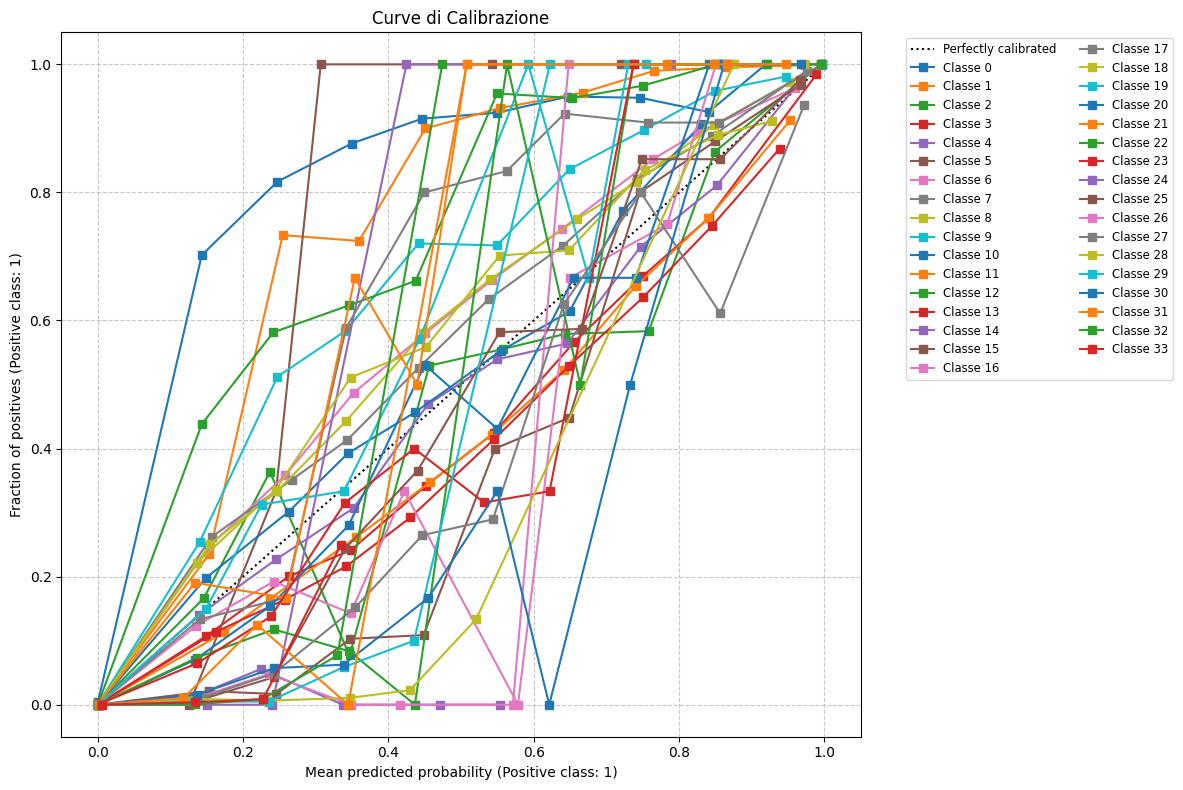


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.89      0.68      0.77      6823
           1       1.00      0.99      1.00     25475
           2       0.99      1.00      1.00      4624
           3       0.64      0.67      0.65     20531
           4       0.64      0.75      0.69      1070
           5       1.00      1.00      1.00     44945
           6       0.78      0.54      0.64     27832
           7       0.57      0.27      0.36     25139
           8       0.79      0.77      0.78     33422
           9       0.81      0.70      0.75      1938
          10       0.48      0.66      0.56     22536
          11       0.49      0.75      0.60     16680
          12       0.64      0.44      0.52      2315
          13       0.38      0.54      0.45     12597
          14       1.00      1.00      1.00     25108
          15       0.38      0.94      0.54       144
          16       0.99      0.99      0.99      2781
    

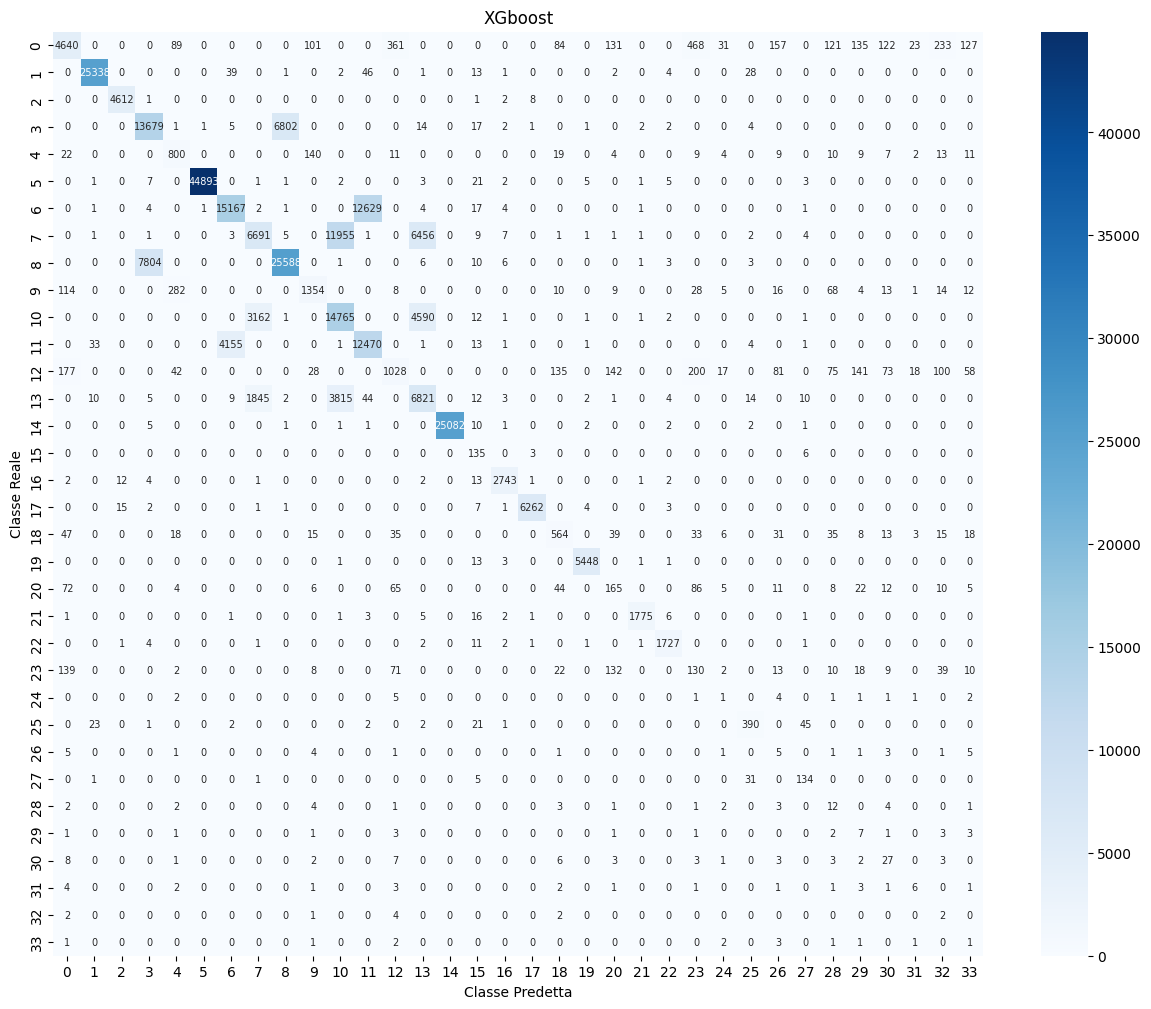

In [23]:
# XGboost
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_sample_weight

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Calcolo e assegno pesi differenti a seconda della rarità delle classi, questo sempre dovuto allo sbilanciamento del dataset
weight = compute_sample_weight(class_weight='balanced', y=y_train)
xgb_model = XGBClassifier(
    n_estimators=150,          
    max_depth=8,               # provo una profondità bassa suggerita da Xgboost
    learning_rate=0.2,         # Tasso di apprendimento 
    subsample=0.6,             # + Velocità : Usa solo il 60% delle righe per ogni albero
    colsample_bytree=0.6,      # + Velocità : Usa solo il 60% delle colonne per ogni albero
    tree_method='hist',        # Utilizzo un motodo ad istogramma per ridurre i tempi
    #eval_metric='mlogloss',    # Indica quale formula matematica utilizzare per capire se sta migliorando o peggiorando durante la creazione degli alberi. essendo il target multiclasse uso mlogloss
    #early_stopping_rounds=10,  # Se per X alberi di fila non migliora, si ferma.
    n_jobs=-1,                 # Usa tutti i core del processore
    random_state=42                   
)

calibrated_xgb = CalibratedClassifierCV(xgb_model, method='isotonic', cv=3)

# xgb_model.fit(
    #X_train, y_train, 
    #sample_weight=weight,
    #eval_set=[(X_test, y_test)],       # li uso per poter vedere le prestazioni
    #verbose=10                         # stampa i progressi ogni 50 alberi
#)

calibrated_xgb.fit(X_train, y_train, sample_weight=weight)

y_pred_xgb = calibrated_xgb.predict(X_test)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb, average='weighted', zero_division=0)
recall_xgb = recall_score(y_test, y_pred_xgb, average='weighted')
f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')

print(f"Accuracy: {accuracy_xgb:.2f}")
print(f"Precision: {precision_xgb:.2f}")
print(f"Recall: {recall_xgb:.2f}")
print(f"F1-Score: {f1_xgb:.2f}")

# -- GRAFICO --
y_prob = calibrated_xgb.predict_proba(X_test)
plt.figure(figsize=(12, 8))
asse_grafico = plt.gca()

for classe in range(34):
    y_binario = (y_test == classe).astype(int)
    prob_classe = y_prob[:, classe]
    
    CalibrationDisplay.from_predictions(
        y_binario,                   
        prob_classe,               
        n_bins=10,                        
        name=f"Classe {classe}",          
        ax=asse_grafico                   
    )

plt.title("Curve di Calibrazione")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize='small')
plt.tight_layout() 
plt.show()

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred_xgb, zero_division=0))

print("\nCONFUSION MATRIX")
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True,fmt='g', annot_kws={"size":7}, cmap='Blues',cbar=True)
plt.title('XGboost')
plt.xlabel('Classe Predetta')
plt.ylabel('Classe Reale')
plt.show()

# TEST
# Prova con n_estimators = 100 e test/train di 80%20% e learning_rate=0.1, Risultati: Accuracy: 0.74, Precision: 0.78, Recall: 0.74, F1-Score: 0.74 T_Esec: 3:37
# Prova con n_estimators = 100 e test/train di 80%20% e learning_rate=0.2, Risultati: Accuracy: 0.75, Precision: 0.78, Recall: 0.75, F1-Score: 0.75 T_Esec: 3:57
# Prova con n_estimators = 100 e test/train di 80%20% e learning_rate=0.5, Risultati: Accuracy: 0.74, Precision: 0.77, Recall: 0.74, F1-Score: 0.74 T_Esec: :49 -- In questo test è scattato l'early-stop a 24 giri
# Prova con n_estimators = 100 e test/train di 80%20% e learning_rate=0.5, Risultati: Accuracy: 0.74, Precision: 0.77, Recall: 0.74, F1-Score: 0.74 T_Esec: 1:29 -- in questo ho aumentato l'early-stop da 10 a 20

# Prova con n_estimators = 300 e test/train di 80%20% e learning_rate=0.2, Risultati: Accuracy: 0.76, Precision: 0.78, Recall: 0.76, F1-Score: 0.76 T_Esec 10:00 -- Noto che dal 100 giro in poi il miglioramento è minimo

# Prova con n_estimators = 150 e test/train di 80%20%, learning_rate=0.2 e max_depth=8, Risultati: Accuracy: 0.77, Precision: 0.78, Recall: 0.77, F1-Score: 0.76 -- Modifico il max_depth da 4 a 8, l'accuratezza è aumentata ma non notevolemnte
# Prova con n_estimators = 150 e test/train di 80%20%, learning_rate=0.2 e max_depth=16, Risultati: Accuracy: 0.77, Precision: 0.78, Recall: 0.77, F1-Score: 0.76 T_Esec: 3:20 --Modifico il max_depth da 8 a 16, nessun miglioramento

# Prova con n_estimators = 150 e test/train di 80%20%, learning_rate=0.2 e max_depth=8, Risultati: Accuracy: 0.77, Precision: 0.78, Recall: 0.77, F1-Score: 0.76 T_Esec: 6,16 -- Dopo aver rimosso subsample e colsample_bytree. nessun miglioramento, solo aumento di tempo di esecuzione

# OSSERVAZIONI
# Nonostante i vari test fatti il modello raggiunge uno stallo di accuratezza al 77%, L'uso di subsample=0.6 e colsample_bytree=0.6 ha ridotto notevolmente i tempi nonostante non abbia influito sull'efficacia del modello
# L'unico test rimasto da effettuare per verificare un eventuale aumento dell'efficacia di questi ultimi due modelli è aumentare il numero di alberi notevolemnte. ma questo causa un aumento importante dei tempi di esecuzione,
# rendendo obbbligatorio effettuare test su dataset di dimensioni notevolemnte minori (quindi con il rischio di perdere realisticità)
# Anche con questo modello i risultati non sono sufficienti endendo necessario il passaggio ad architetture di Deep Learning (Reti Neurali)

# TEST 2
# Aggiungo calibrazione con CalibratedClassifierCV, Risultati:Accuracy: 0.76, Precision: 0.78, Recall: 0.76, F1-Score: 0.76 -- Per poter aggiungere questa ho dovuto eliminare l'early_stop. 
# Il grafico sembra abbastanza confusionario, anche se la percentuale di accuratezza e F1 è molto simile a quella del Random Forest, questo modello mostra meno affidabilità

Epoch 1/100
4566/4566 ━━━━━━━━━━━━━━━━━━━━ 27s 6ms/step - accuracy: 0.7333 - loss: 0.5430 - val_accuracy: 0.7359 - val_loss: 0.4922
Epoch 2/100
4566/4566 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.7468 - loss: 0.4958 - val_accuracy: 0.7544 - val_loss: 0.4791
Epoch 3/100
4566/4566 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.7501 - loss: 0.4886 - val_accuracy: 0.7572 - val_loss: 0.4758
Epoch 4/100
4566/4566 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.7528 - loss: 0.4842 - val_accuracy: 0.7587 - val_loss: 0.4720
Epoch 5/100
4566/4566 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.7577 - loss: 0.4782 - val_accuracy: 0.7639 - val_loss: 0.4574
Epoch 6/100
4566/4566 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.7651 - loss: 0.4660 - val_accuracy: 0.7707 - val_loss: 0.4511
Epoch 7/100
4566/4566 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.7658 - loss: 0.4637 - val_accuracy: 0.7700 - val_loss: 0.4497
Epoch 8/100
4566/4566 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.7656 -

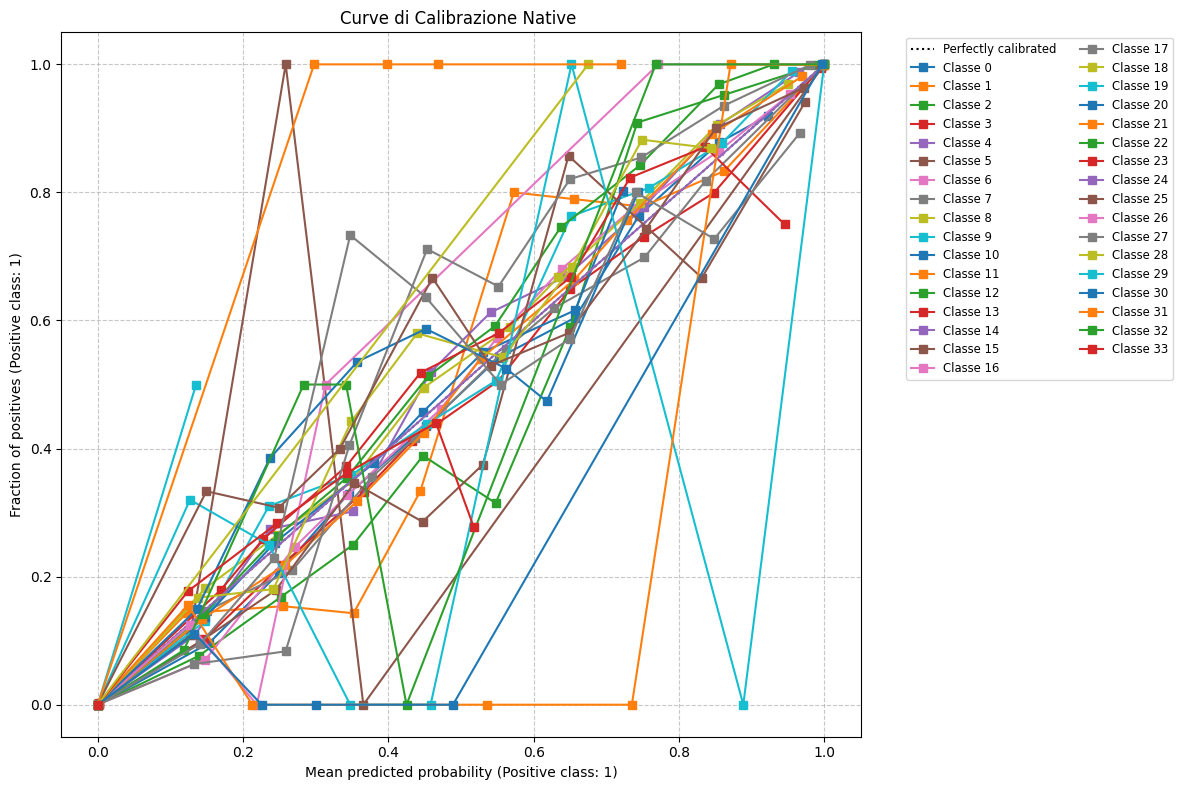


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.71      0.91      0.80      3432
           1       1.00      1.00      1.00     12761
           2       0.97      0.97      0.97      2398
           3       0.78      0.46      0.58     10210
           4       0.72      0.54      0.62       574
           5       1.00      1.00      1.00     22473
           6       0.68      0.87      0.76     13838
           7       0.47      0.53      0.50     12559
           8       0.74      0.92      0.82     16669
           9       0.73      0.61      0.66       991
          10       0.47      0.59      0.52     11187
          11       0.59      0.31      0.40      8297
          12       0.58      0.56      0.57      1164
          13       0.65      0.20      0.30      6386
          14       1.00      1.00      1.00     12571
          15       0.38      0.63      0.48        68
          16       1.00      0.98      0.99      1408
    

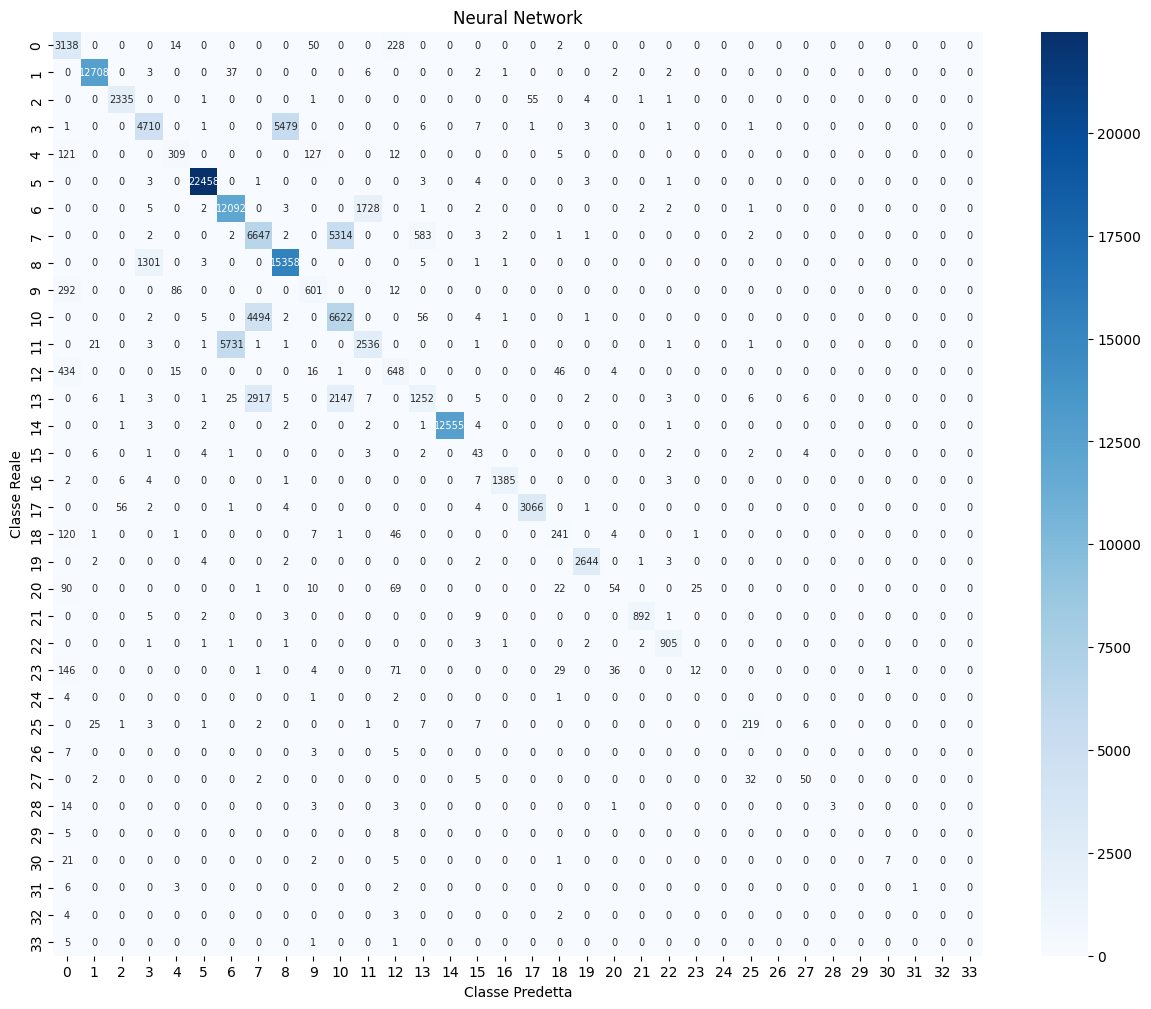

In [24]:
# Rete Neurale
from sklearn.preprocessing import StandardScaler   

import tensorflow as tf
from tensorflow import keras
from keras import optimizers, layers
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

X_train, X_temp, y_train, y_temp = train_test_split(X,y,test_size=0.2,random_state=42)
X_val, X_test, y_val, y_test = train_test_split (X_temp,y_temp, test_size=0.5, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)
num_classes = 34


model = keras.Sequential([
    layers.InputLayer(shape=(X_train.shape[1],)),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),                    # Spegne il 20% dei neuroni, previene l'overfitting
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"), 
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

#Applico un early stop anche in questo modello per evitare di sprecare tempo prezioso 
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)

#weight = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
#diz_weight = dict(enumerate(weight))            #Le reti neurali necessitano di un dizionario per i pesi

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=256,
    #class_weight=diz_weight,            
    verbose=1,
    callbacks=[early_stop]
)

y_pred_probs = model.predict(X_test)        # invece di restituire un valore unico la rete neurale restituisce la probabilità per ogni classe 
y_pred_rn = np.argmax(y_pred_probs, axis=1) # Prende la probabilità più alta

accuracy_rn = accuracy_score(y_test, y_pred_rn)
precision_rn = precision_score(y_test, y_pred_rn, average='weighted', zero_division=0)
recall_rn = recall_score(y_test, y_pred_rn, average='weighted')
f1_rn = f1_score(y_test, y_pred_rn, average='weighted')

print(f"Accuracy: {accuracy_rn:.2f}")
print(f"Precision: {precision_rn:.2f}")
print(f"Recall: {recall_rn:.2f}")
print(f"F1-Score: {f1_rn:.2f}")

# -- GRAFICO --

plt.figure(figsize=(12, 8))
asse_grafico = plt.gca()

for classe in range(34):
    y_binario = (y_test == classe).astype(int)
    prob_classe = y_pred_probs[:, classe] # Prendiamo le probabilità native del Softmax
    
    CalibrationDisplay.from_predictions(
        y_binario,                   
        prob_classe,               
        n_bins=10,                        
        name=f"Classe {classe}",          
        ax=asse_grafico                   
    )
    
plt.title("Curve di Calibrazione Native ")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize='small')
plt.tight_layout() 
plt.show()

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred_rn, zero_division=0))

print("\nCONFUSION MATRIX")
cm = confusion_matrix(y_test, y_pred_rn)
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True,fmt='g', annot_kws={"size":7}, cmap='Blues',cbar=True)
plt.title('Neural Network')
plt.xlabel('Classe Predetta')
plt.ylabel('Classe Reale')
plt.show()

#TEST
# Test con train/test/val di 70%15%15% e n_neuroni = 64 Risultati: Accuracy: 0.77, Precision: 0.78, Recall: 0.77, F1-Score: 0.74 T_esec: 4:46 
# Test con train/test/val di 80%10%10% e n_neuroni = 64 Risultati: Accuracy: 0.77, Precision: 0.78, Recall: 0.77, F1-Score: 0.74 T_esec: 2:43
# Test con train/test/val di 80%10%10% e n_neuroni = 256 Risultati: Accuracy: 0.77, Precision: 0.78, Recall: 0.77, F1-Score: 0.77 T_esec: 6:49 -- Aumento i numero da 64 a 256 e il dropuot da 0.2 a 0.3. Noto che l'accuratezza è rimasta uguale ma F1 è aumentato quindi le statistiche sono migliorate, a discapito dei tempi
# Test con train/test/val di 80%10%10% e n_neuroni = 256 batch_size 256 learning_rate 1e-3 Risultati: Accuracy: 0.77, Precision: 0.78, Recall: 0.77 F1-Score: 0.76 T_esec: 2:52  -- Rimuovo i pesi e alzo il learning rate testando solo con un aumento del batch_size. 

#OSSERVAZIONI
# Assegnare un peso alle classi per questo modello non si è rivelato un passagio utile.
# Anche con questo modello i risultati non superano il 77% di accuratezza ma si nota un aumnto per quanto riguarda F1_score e la netta riduzione dei tempi.

#TEST 2
# Applico un straficazione nello split (stratify=y) per bilanciare ancora di più li split di addestramento e test.
# Risultati: Accuracy: 0.77 Precision: 0.78 Recall: 0.77 F1-Score: 0.75 T_esec: 5:15 -- Rimuovo

#Applico un nuovo layer aumentando i neuroni da 256 a 512, Risultati: non sufficienti
